<a href="https://colab.research.google.com/github/dquin144/CIS5370-Project/blob/main/CybersecIntrusionDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ICS Intrustion Detection Pipeline

##### 1. Data Collection and Processing
##### 2. Feature Extraction
##### 3. Detection Methods
##### 4. Evaluation

### 1. Data Collection and Processing

#### Configure Kaggle Credentials

In [27]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


mv: cannot stat 'kaggle.json': No such file or directory


#### Test API Connection

In [28]:
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           5659        143                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13002        299                1  
sumeakash/impact-of-social-media-on-health                         Impact of Social Media on Health                         18598  2026-04-05 06:53:55.953000           3491         81     

#### Download SWaT Dataset

In [29]:
!kaggle datasets download -d vishala28/swat-dataset-secure-water-treatment-system

Dataset URL: https://www.kaggle.com/datasets/vishala28/swat-dataset-secure-water-treatment-system
License(s): CC0-1.0
swat-dataset-secure-water-treatment-system.zip: Skipping, found more recently modified local copy (use --force to force download)


#### Unzip Dataset

In [30]:
!unzip swat-dataset-secure-water-treatment-system.zip

Archive:  swat-dataset-secure-water-treatment-system.zip
replace attack.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: attack.csv              
replace merged.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: merged.csv              y
y

replace normal.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: normal.csv              y
y



#### Load Dataset into Pandas

In [31]:
import pandas as pd

df = pd.read_csv("merged.csv")
df.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


### 2. Feature Extraction

#### Feature Selection, Encoding, Splitting, and Scaling

In [32]:
# Drop timestamp column
df = df.drop(columns=[" Timestamp"], errors="ignore")

# Remove missing values
df = df.dropna()

# Encode labels
df["Normal/Attack"] = df["Normal/Attack"].map({
    "Normal": 0,
    "Attack": 1
})

# Split features and target
X = df.drop(columns=["Normal/Attack"])
y = df["Normal/Attack"]

# Difference features
X_diff = X.diff().fillna(0)
X_diff.columns = [col + "_diff" for col in X.columns]

# Combine features
X_combined = pd.concat([X, X_diff], axis=1)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined )

#### Train/Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 3. Detection Methods

#### Model 1: Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Save feature importance
rf_importance = rf.feature_importances_

#### Model 2: XGBoost

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metrics='logloss'
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

# Save feature importance
xgb_importance = xgb.feature_importances_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:16:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Model 3: Isolation Forest

In [36]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)

pred_iso = iso.predict(X_test)
# Convert output
pred_iso = [1 if p == -1 else 0 for p in pred_iso]

### 4. Evaluation

In [37]:
predictions = {
    "XGBoost": pred_xgb,
    "Random Forest": pred_rf,
    "Isolation Forest": pred_iso
}

#### Classification Report

In [38]:
from sklearn.metrics import classification_report

for name, pred in predictions.items():
    print("\n====================")
    print(name)
    print("====================")
    print(classification_report(y_test, pred))


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79060
           1       1.00      0.98      0.99     10924

    accuracy                           1.00     89984
   macro avg       1.00      0.99      1.00     89984
weighted avg       1.00      1.00      1.00     89984


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79060
           1       1.00      1.00      1.00     10924

    accuracy                           1.00     89984
   macro avg       1.00      1.00      1.00     89984
weighted avg       1.00      1.00      1.00     89984


Isolation Forest
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     79060
           1       0.79      0.65      0.71     10924

    accuracy                           0.94     89984
   macro avg       0.87      0.81      0.84     89984
weighted avg       0.93      0.9

#### Confusion Matrix

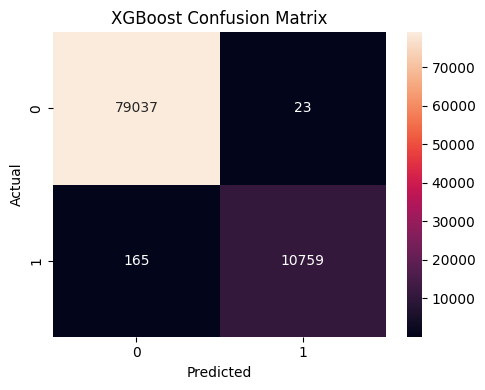

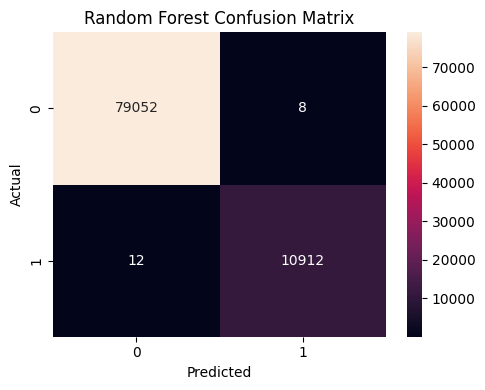

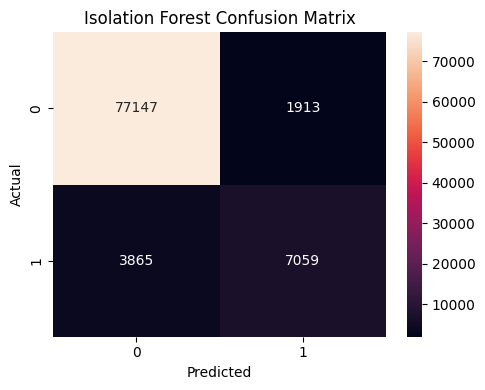

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Loop through all three models and generate confusion matrices
for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="rocket")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#### Comparison Table

In [40]:
import pandas as pd

results = []

for name, pred in predictions.items():
    report = classification_report(y_test, pred, output_dict=True)

    results.append({
        "Model": name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"]
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1-score
0,XGBoost,0.997867,0.984896,0.991339
1,Random Forest,0.999267,0.998902,0.999084
2,Isolation Forest,0.786781,0.646192,0.709590


#### Performance Visualization

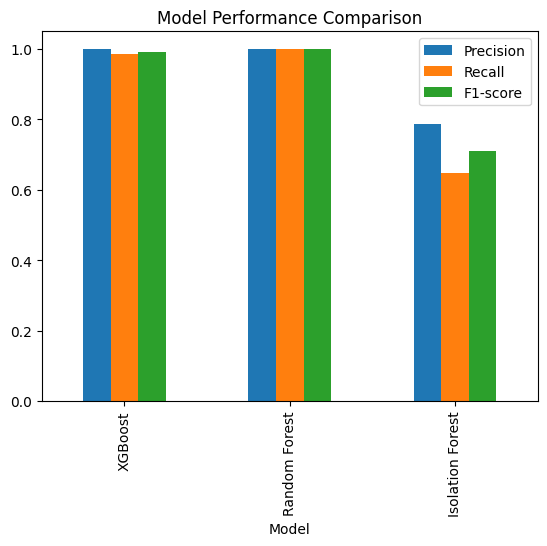

In [41]:
results_df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.show()

#### Feature Importance

In [42]:
import pandas as pd

feature_names = X_combined.columns

rf_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

xgb_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
}).sort_values(by="Importance", ascending=False)

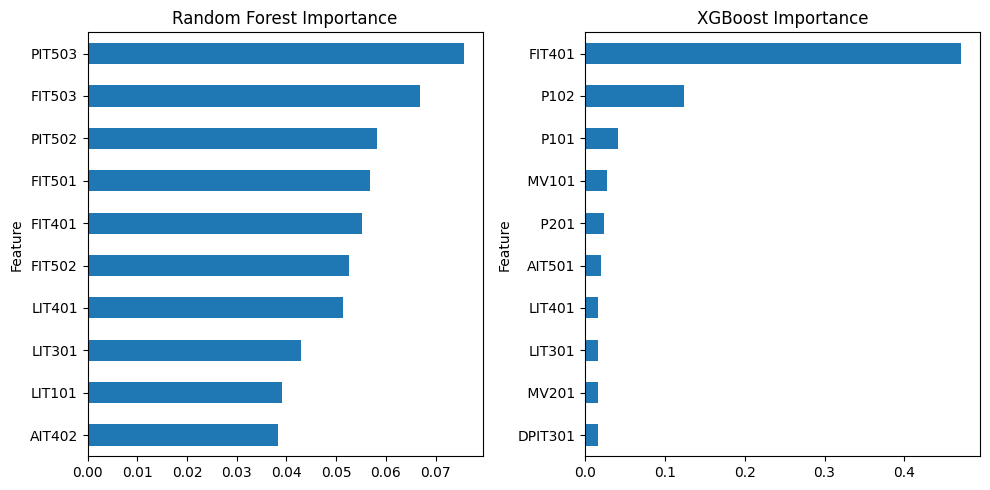

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Random Forest
rf_df.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Random Forest Importance")
axes[0].invert_yaxis()

# XGBoost
xgb_df.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("XGBoost Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()